In [1]:
# Library Imports
import pandas as pd
import numpy as np
import re

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    log_loss
)


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# Load Dataset
df=pd.read_csv('/content/drive/MyDrive/Dataset/Reviews.csv')
print(df.shape)
df.head()

(568454, 10)


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [7]:
# keeping only required columns
df = df[['Summary', 'Text', 'Score']]


In [8]:
# Create Sentiments label
def sentiment_label(score):
    if score <= 2:
        return 0   # Negative
    elif score == 3:
        return 1   # Neutral
    else:
        return 2   # Positive

df['sentiment'] = df['Score'].apply(sentiment_label)


In [9]:
# checking distribution of sentiments
df['sentiment'].value_counts()


,count
sentiment,
2,443777
0,82037
1,42640


# Text Cleaning & preprocessing

In [10]:
import re
from sklearn.feature_extraction.text import TfidfVectorizer

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

df['summary_clean'] = df['Summary'].fillna('').apply(clean_text)

# TF_IDF Vectorization

In [11]:
vectorizer = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1,2)
)

X = vectorizer.fit_transform(df['summary_clean'])
y = df['sentiment']

# Baseline Model 1 (Logistic Regression(Summary Only))

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred_proba = model.predict_proba(X_test)
loss = log_loss(y_test, y_pred_proba)
print(f"Log Loss: {loss:.4f}")



Log Loss: 0.3097


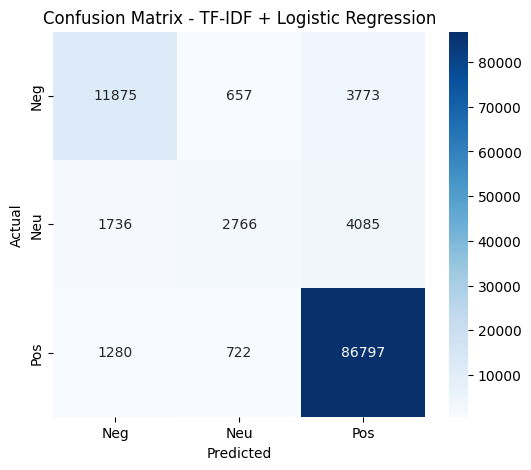

In [13]:
cm = confusion_matrix(y_test, y_pred_proba.argmax(axis=1))

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Neg','Neu','Pos'],
    yticklabels=['Neg','Neu','Pos']
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - TF-IDF + Logistic Regression")
plt.show()


In [14]:
# classification report
from sklearn.metrics import classification_report
y_pred = y_pred_proba.argmax(axis=1)
report = classification_report(y_test, y_pred, target_names=['Negative', 'Neutral', 'Positive'])
print("Classification Report:\n", report)


Classification Report:
               precision    recall  f1-score   support

    Negative       0.80      0.73      0.76     16305
     Neutral       0.67      0.32      0.43      8587
    Positive       0.92      0.98      0.95     88799

    accuracy                           0.89    113691
   macro avg       0.79      0.68      0.71    113691
weighted avg       0.88      0.89      0.88    113691



In [15]:
# Class mapping
label_map = {
    0: "Negative",
    1: "Neutral",
    2: "Positive"
}


# Prediction Function

In [16]:
def predict_sentiment(summary_text):
    # 1. Clean text
    cleaned_text = clean_text(summary_text)

    # 2. TF-IDF transform
    vectorized_text = vectorizer.transform([cleaned_text])

    # 3. Predict class
    predicted_class = model.predict(vectorized_text)[0]

    # 4. Predict probabilities
    predicted_proba = model.predict_proba(vectorized_text)[0]

    return {
        "Predicted Sentiment": label_map[predicted_class],
        "Confidence Scores": {
            "Negative": round(predicted_proba[0], 4),
            "Neutral": round(predicted_proba[1], 4),
            "Positive": round(predicted_proba[2], 4)
        }
    }



In [17]:
#Predicting sentiment for a new review summary
user_summary = "This product is absolutely amazing and works perfectly"

result = predict_sentiment(user_summary)

print(result)


{'Predicted Sentiment': 'Positive', 'Confidence Scores': {'Negative': np.float64(0.008), 'Neutral': np.float64(0.0047), 'Positive': np.float64(0.9872)}}


In [18]:
#Predicting sentiment for a new review summary
user_summary = "This product doesn't meet my expectation"

result = predict_sentiment(user_summary)

print(result)


{'Predicted Sentiment': 'Negative', 'Confidence Scores': {'Negative': np.float64(0.6554), 'Neutral': np.float64(0.0807), 'Positive': np.float64(0.2639)}}


In [19]:
#Predicting sentiment for a new review summary
user_summary = "The headphone's sound quality is decent but could be better"

result = predict_sentiment(user_summary)

print(result)


{'Predicted Sentiment': 'Neutral', 'Confidence Scores': {'Negative': np.float64(0.2907), 'Neutral': np.float64(0.531), 'Positive': np.float64(0.1782)}}


# Logistic Regression with TF_IDF using review_text and summary both

In [20]:
df['review_text'] = (
    df['Summary'].fillna('') + " " + df['Text'].fillna('')
)


In [21]:
# Text cleaning on review text
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

df['review_text_clean'] = df['review_text'].apply(clean_text)
df[['review_text', 'review_text_clean']].head()


,review_text,review_text_clean
0,Good Quality Dog Food I have bought several of...,good quality dog food i have bought several of...
1,Not as Advertised Product arrived labeled as J...,not as advertised product arrived labeled as j...
2,"""Delight"" says it all This is a confection tha...",delight says it all this is a confection that ...
3,Cough Medicine If you are looking for the secr...,cough medicine if you are looking for the secr...
4,Great taffy Great taffy at a great price. The...,great taffy great taffy at a great price ther...


In [22]:
#train test split
X = df['review_text_clean']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [23]:
# Tf-IDF Vectorization
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=5
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


In [24]:
y_pred = model.predict(X_test_tfidf)
y_pred_proba = model.predict_proba(X_test_tfidf)



# Evaluation Metrics

In [25]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.7607374374400788


In [26]:
print(classification_report(
    y_test,
    y_pred,
    target_names=['Negative', 'Neutral', 'Positive']
))


              precision    recall  f1-score   support

    Negative       0.15      0.03      0.05     16407
     Neutral       0.19      0.00      0.00      8528
    Positive       0.78      0.97      0.86     88756

    accuracy                           0.76    113691
   macro avg       0.37      0.33      0.31    113691
weighted avg       0.65      0.76      0.68    113691



In [27]:
# Loss Function
loss = log_loss(y_test, y_pred_proba)
print(f"Log Loss: {loss:.4f}")


Log Loss: 0.7321


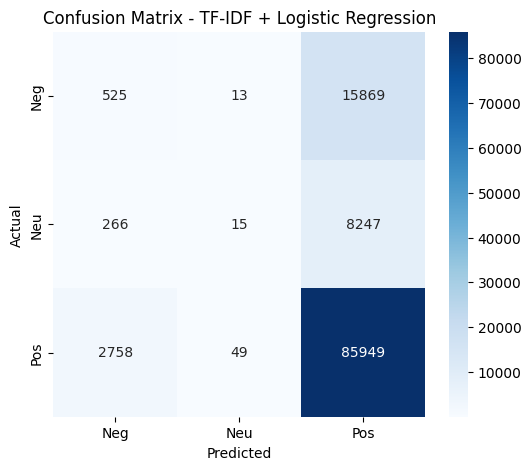

In [28]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Neg','Neu','Pos'],
    yticklabels=['Neg','Neu','Pos']
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - TF-IDF + Logistic Regression")
plt.show()


In [29]:
# prediction function
def predict_sentiment(review_text):
    # 1. Clean text
    review_text_cleaned = clean_text(review_text)

    # 2. TF-IDF transform (NOT fit_transform)
    vectorized_text = tfidf.transform([review_text_cleaned])

    # 3. Predict class
    predicted_class = model.predict(vectorized_text)[0]

    # 4. Predict probabilities
    predicted_proba = model.predict_proba(vectorized_text)[0]

    return {
        "Predicted Sentiment": label_map[predicted_class],
        "Confidence Scores": {
            "Negative": predicted_proba[0],
            "Neutral": predicted_proba[1],
            "Positive": predicted_proba[2]
        }
    }


In [30]:
# Predicting sentiment for a new review summary
user_review = "I am extremely satisfied with this purchase. The product works like a charm and exceeded my expectations."

result = predict_sentiment(user_review)

print(result)


{'Predicted Sentiment': 'Negative', 'Confidence Scores': {'Negative': np.float64(0.49452755858954633), 'Neutral': np.float64(0.06332086299083256), 'Positive': np.float64(0.442151578419621)}}


In [31]:
# Actual vs Predicted Distribution
comparison = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_pred[:10]
})

comparison


,Actual,Predicted
0,2,2
1,1,2
2,2,0
3,2,2
4,2,0
5,0,2
6,2,2
7,2,2
8,2,2
9,0,2


# Logistic Regression With TF-IDF using text only

In [32]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df['clean_text'] = df['Text'].apply(clean_text)


In [33]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], df['sentiment'], test_size=0.2, random_state=42
)


In [34]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    stop_words="english",
    min_df=5
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


In [35]:
# Train logistic Regression
model = LogisticRegression(max_iter=1000, n_jobs=-1)
model.fit(X_train_tfidf, y_train)


LogisticRegression(max_iter=1000, n_jobs=-1)

In [36]:
# Evaluation Of Model
y_pred = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=label_map.values()))


Accuracy: 0.8679227027645108

Classification Report:

              precision    recall  f1-score   support

    Negative       0.74      0.68      0.70     16181
     Neutral       0.52      0.18      0.26      8485
    Positive       0.90      0.97      0.93     89025

    accuracy                           0.87    113691
   macro avg       0.72      0.61      0.63    113691
weighted avg       0.85      0.87      0.85    113691



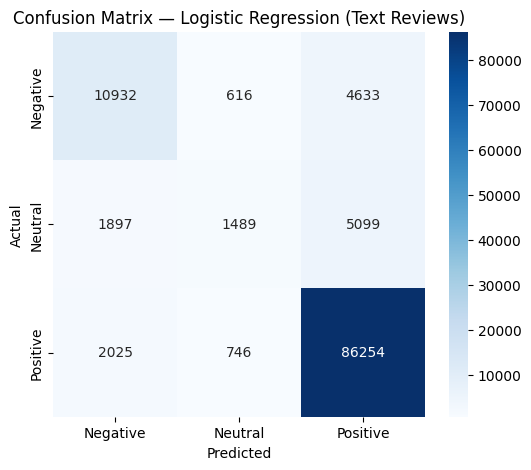

In [37]:
# Confusion Matrix plot
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_map.values(),
            yticklabels=label_map.values())

plt.title("Confusion Matrix — Logistic Regression (Text Reviews)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [38]:
#Prediction function
def predict_sentiment(review_text):
    cleaned_text = clean_text(review_text)
    vectorized_text = vectorizer.transform([cleaned_text])

    predicted_class = model.predict(vectorized_text)[0]
    predicted_proba = model.predict_proba(vectorized_text)[0]

    return {
        "Predicted Sentiment": label_map[predicted_class],
        "Confidence Scores": {
            "Negative": round(predicted_proba[0], 4),
            "Neutral": round(predicted_proba[1], 4),
            "Positive": round(predicted_proba[2], 4)
        }
    }


In [39]:
predict_sentiment("This product quality is amazing, I love it")


{'Predicted Sentiment': 'Positive',
 'Confidence Scores': {'Negative': np.float64(0.0003),
  'Neutral': np.float64(0.0008),
  'Positive': np.float64(0.999)}}

In [40]:
# Loss Function
from sklearn.metrics import log_loss

# Predicted probabilities
y_test_proba = model.predict_proba(X_test_tfidf)

# Compute loss
loss = log_loss(y_test, y_test_proba)

print(f"Log Loss (Test Set): {loss:.4f}")


Log Loss (Test Set): 0.3563


In [41]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, model.predict(X_test_tfidf))

print(f"Accuracy : {accuracy:.4f}")
print(f"Log Loss : {loss:.4f}")


Accuracy : 0.8679
Log Loss : 0.3563


# Models Evaluation by graph & Soft Voting

In [42]:
acc_summary = 0.89
acc_text = 0.87
acc_combined = 0.76


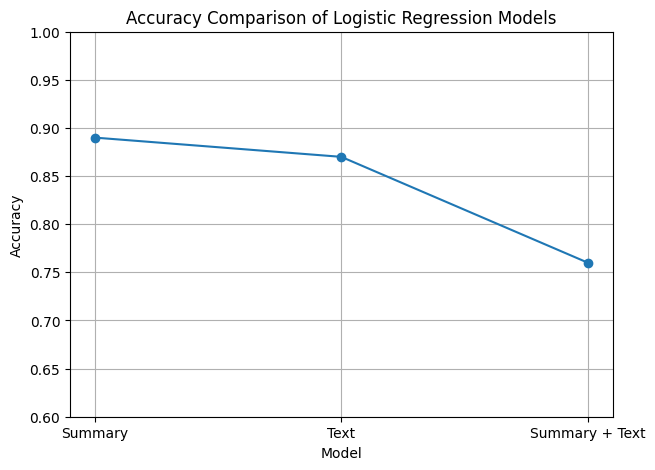

In [43]:
import matplotlib.pyplot as plt

models = ["Summary", "Text", "Summary + Text"]
accuracies = [acc_summary, acc_text, acc_combined]

plt.figure(figsize=(7,5))
plt.plot(models, accuracies, marker='o')
plt.title("Accuracy Comparison of Logistic Regression Models")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0.6, 1.0)
plt.grid(True)
plt.show()
